# Notebook 02 : Visualisation des données

**Projet :** AI Data Job Market — Prédiction de Salaire  
**Fichier source :** `data/raw/AI_Job_Market_Dataset.csv` *(dataset original — pour les labels lisibles)*  

>  **Pourquoi on utilise le dataset original et pas le nettoyé ?**  
> Le dataset nettoyé a remplacé les textes (`job_title`, `country`...) par des colonnes 0/1  
> grâce au One-Hot Encoding. Ces colonnes ne sont pas lisibles dans un graphique.  
> Pour visualiser, on repart du dataset original et on applique seulement les nettoyages  
> de base (minuscules, suppression des outliers salary).

---
### Graphiques produits dans ce notebook
| # | Graphique | Variables | Ce qu'on cherche à voir |
|---|---|---|---|
| 1 | Histogramme | `salary` | Distribution générale des salaires |
| 2 | Boxplot | `salary` par `job_title` | Quel métier est le mieux payé ? |
| 3 | Boxplot | `salary` par `experience_level` | L'expérience influence-t-elle le salaire ? |
| 4 | Barplot | `salary` médian par `country` | Les salaires varient-ils selon le pays ? |
| 5 | Barplot | `salary` médian par `company_industry` | Quel secteur paie le mieux ? |
| 6 | Scatter | `years_experience` vs `salary` | Plus d'années = plus de salaire ? |
| 7 | Heatmap | Corrélations | Quelles variables influencent le plus le salary ? |
| 8 | Barplot | `total_skills` vs `salary` | Plus de compétences = plus de salaire ? |

## Étape 1 : Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# Style global des graphiques
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('Bibliothèques importées avec succès.')
print(f'  pandas     : {pd.__version__}')
print(f'  matplotlib : {plt.matplotlib.__version__}')
print(f'  seaborn    : {sns.__version__}')

Bibliothèques importées avec succès.
  pandas     : 2.3.3
  matplotlib : 3.10.8
  seaborn    : 0.13.2


## Étape 2 : Chargement et préparation des données

On charge le dataset **original** et on applique uniquement les transformations  
nécessaires pour que les graphiques soient lisibles et cohérents.

In [2]:
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
RAW_PATH = os.path.join(BASE_DIR, '..', 'data', 'raw', 'AI_Job_Market_Dataset.csv')

df = pd.read_csv(RAW_PATH)

# Nettoyage minimal pour la visualisation
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Standardiser le texte
text_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

# Supprimer les 4 outliers salary identifiés lors du nettoyage
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['salary'] >= Q1 - 1.5*IQR) & (df['salary'] <= Q3 + 1.5*IQR)]

# Créer total_skills pour les graphiques
skill_cols = [c for c in df.columns if 'skills_' in c]
df['total_skills'] = df[skill_cols].sum(axis=1)

print(f'Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(df.head(3))

Dataset chargé : 10341 lignes × 20 colonnes
   job_id                  job_title company_size company_industry    country  \
0       1                ai engineer      startup           retail     canada   
1       2  machine learning engineer          mnc       technology  australia   
2       3  machine learning engineer          mnc       technology    germany   

  remote_type experience_level  years_experience education_level  \
0      remote           senior                 2          master   
1      hybrid              mid                 0        bachelor   
2      onsite              mid                14          master   

   skills_python  skills_sql  skills_ml  skills_deep_learning  skills_cloud  \
0              0           0          0                     1             0   
1              1           1          1                     0             1   
2              1           0          1                     0             1   

   salary  job_posting_month  job_posting

## Graphique 1 : Distribution des salaires (Histogramme)

**Objectif :** Comprendre la forme générale de la distribution des salaires.  
- Est-ce que les salaires sont concentrés autour d'une valeur centrale ?  
- Y a-t-il une asymétrie (beaucoup de petits salaires et peu de très grands) ?

**Type de graphique :** Histogramme + courbe KDE (densité)
- L'**histogramme** montre le nombre d'offres par tranche de salaire
- La **courbe KDE** montre la tendance générale (lissage de l'histogramme)

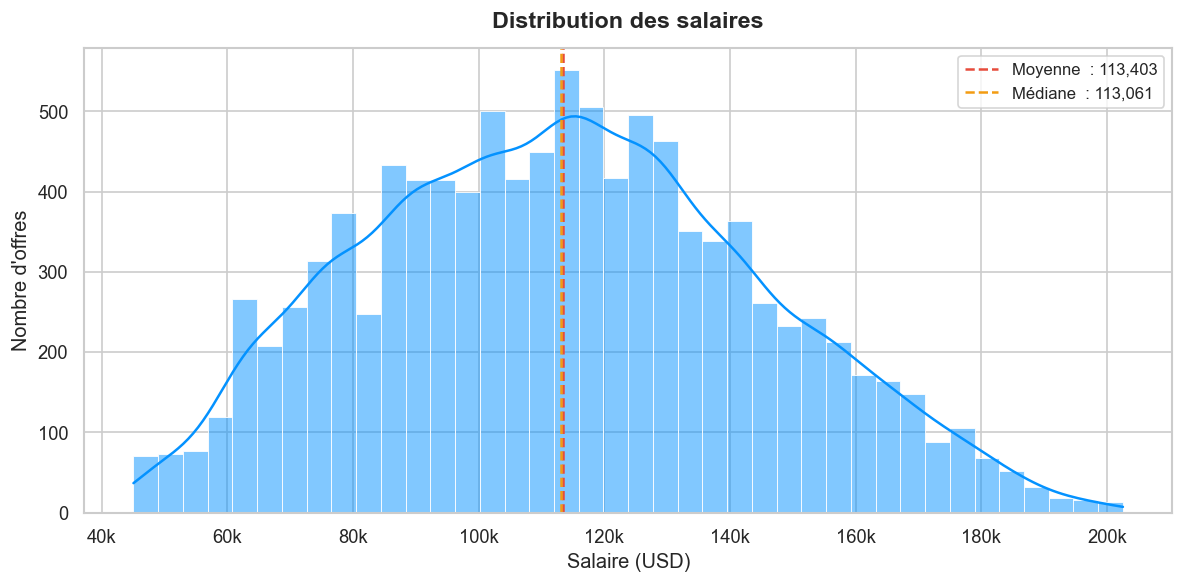

Min     : 45,083
Max     : 202,523
Moyenne : 113,403
Médiane : 113,061


In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=df,
    x='salary',
    bins=40,
    kde=True,                # affiche la courbe de densité
    color="#0492FF",         # jaune clair uniforme
    edgecolor='white',
    linewidth=0.5,
    ax=ax
)

# Lignes de référence : moyenne et médiane
mean_salary = df['salary'].mean()
median_salary = df['salary'].median()

ax.axvline(mean_salary,   color='#E74C3C', linestyle='--', linewidth=1.5,
           label=f'Moyenne  : {mean_salary:,.0f}')
ax.axvline(median_salary, color='#F39C12', linestyle='--', linewidth=1.5,
           label=f'Médiane  : {median_salary:,.0f}')

# Titres et axes
ax.set_title('Distribution des salaires', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Salaire (USD)', fontsize=12)
ax.set_ylabel('Nombre d\'offres', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend(fontsize=10)

plt.tight_layout()

# Sauvegarde
figures_path = os.path.join(BASE_DIR, '..', 'figures')
os.makedirs(figures_path, exist_ok=True)
plt.savefig(os.path.join(figures_path, 'g1_distribution_salary.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Statistiques
print(f'Min     : {df["salary"].min():,.0f}')
print(f'Max     : {df["salary"].max():,.0f}')
print(f'Moyenne : {mean_salary:,.0f}')
print(f'Médiane : {median_salary:,.0f}')

## Graphique 2 : Salaire par intitulé de poste (Boxplot)

**Objectif :** Comparer les distributions de salaires entre les différents métiers.

**Type de graphique :** Boxplot (boîte à moustaches)

**Comment lire un boxplot ?**
```
    |----[  Q1 === MÉDIANE === Q3  ]----|
  Moustache  Boîte (50% des données)  Moustache
    basse                               haute
  ●  ← points isolés = valeurs extrêmes (mais pas outliers supprimés)
```
- La **ligne centrale** = médiane (valeur du milieu)
- La **boîte** = 50% des salaires les plus "typiques"
- Les **moustaches** = étendue des valeurs normales
- Les **points** = valeurs éloignées de la norme

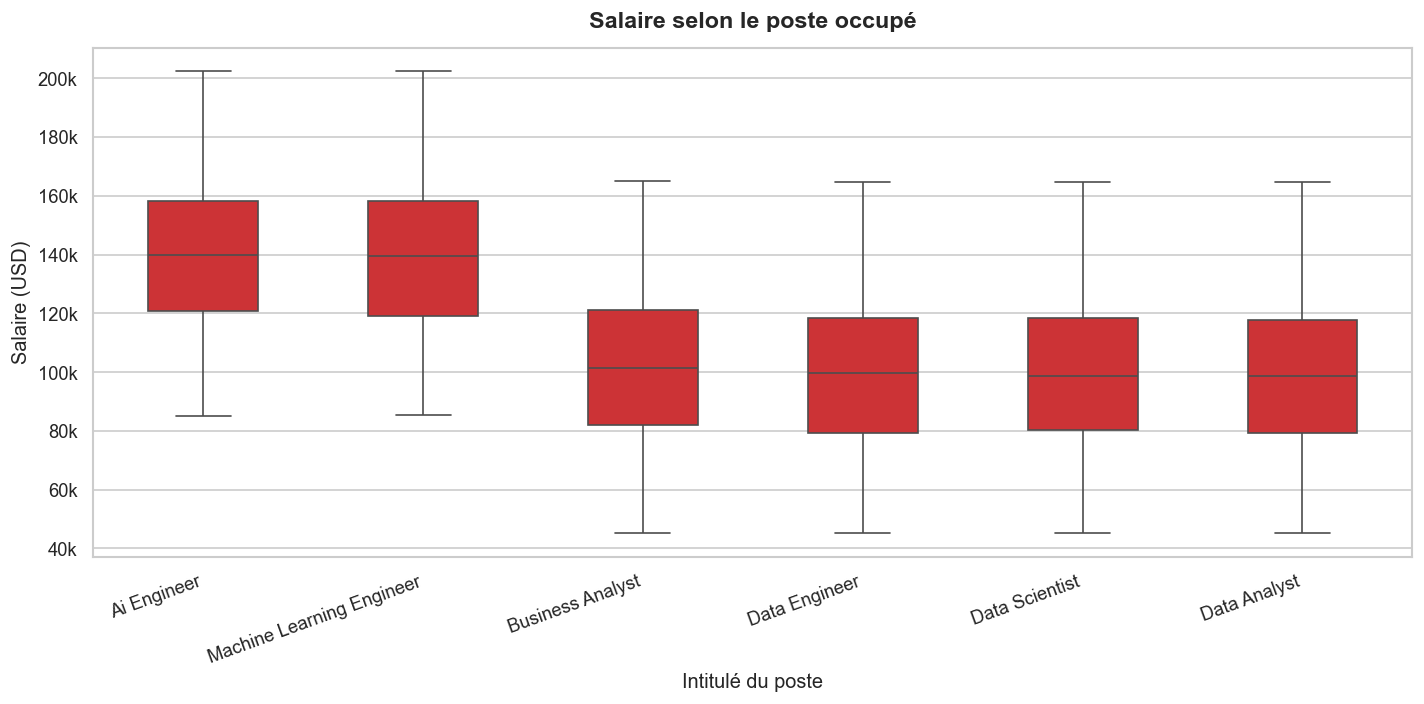

Médiane salary par poste :
job_title
ai engineer                  139,814
machine learning engineer    139,618
business analyst             101,553
data engineer                 99,660
data scientist                98,821
data analyst                  98,595
Name: salary, dtype: object


In [4]:
# Calcul de l'ordre des postes par salaire médian
ordre = (
    df.groupby('job_title')['salary']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 6))

# Création d'un dégradé rose uniforme pour les boxplots
palette_rose = {job: "#E51A1E" for job in ordre}  # rose clair uniforme

sns.boxplot(
    data=df,
    x='job_title',
    y='salary',
    order=ordre,
    hue='job_title',
    palette=palette_rose,
    legend=False,
    width=0.5,
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.4),
    ax=ax,
    dodge=False  # empêche séparation multiple des boxplots
)

# Fixer les ticks pour éviter le warning
ax.set_xticks(range(len(ordre)))
ax.set_xticklabels([t.title() for t in ordre], rotation=20, ha='right', fontsize=11)

ax.set_title('Salaire selon le poste occupé', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Intitulé du poste', fontsize=12)
ax.set_ylabel('Salaire (USD)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, '..', 'figures', 'g2_salary_par_jobtitle.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Affichage des médianes
print('Médiane salary par poste :')
print(df.groupby('job_title')['salary']
      .median()
      .sort_values(ascending=False)
      .apply(lambda x: f'{x:,.0f}'))

## Graphique 3 : Salaire par niveau d'expérience (Boxplot)

**Objectif :** Vérifier si le niveau d'expérience (Entry / Mid / Senior) est bien  
corrélé avec le salaire ; ce qui est attendu dans un marché de l'emploi normal.

C:\Users\Admin\AppData\Local\Temp\ipykernel_9968\1901770383.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


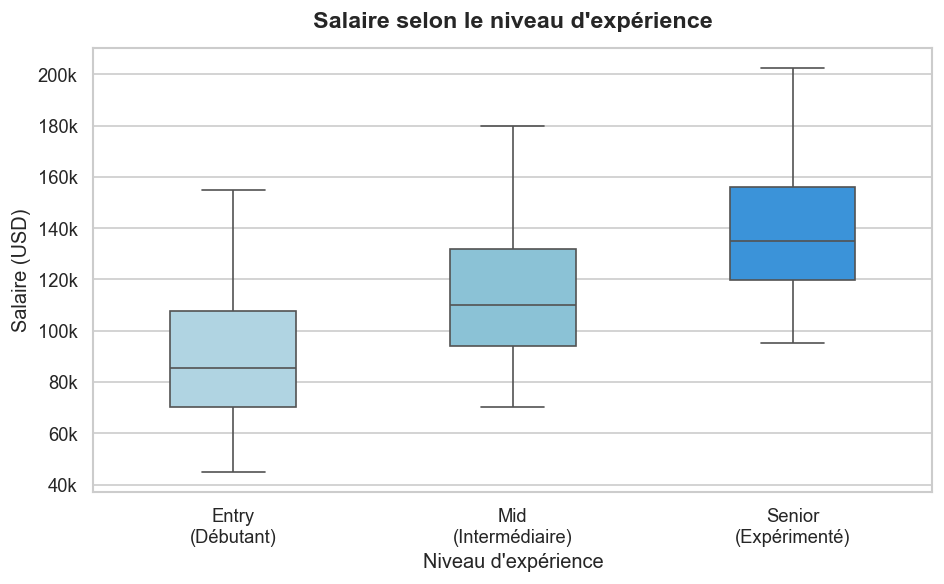

Médiane salary par niveau :
  entry  : 85,463
  mid    : 109,928
  senior : 134,878


In [5]:
ordre_exp = ['entry', 'mid', 'senior']
labels_exp = ['Entry\n(Débutant)', 'Mid\n(Intermédiaire)', 'Senior\n(Expérimenté)']

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='experience_level',
    y='salary',
    order=ordre_exp,
    palette=['#a8d8ea', '#7ec8e3', '#2196f3'],
    width=0.45,
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.4),
    ax=ax
)

# Fixer les ticks pour éviter le warning
ax.set_xticks(range(len(ordre_exp)))
ax.set_xticklabels(labels_exp, fontsize=11)

ax.set_title("Salaire selon le niveau d'expérience", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Niveau d'expérience", fontsize=12)
ax.set_ylabel('Salaire (USD)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, '..', 'figures', 'g3_salary_par_experience.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Médiane salary par niveau :')
for niv in ordre_exp:
    med = df[df['experience_level']==niv]['salary'].median()
    print(f'  {niv:6s} : {med:,.0f}')

## Graphique 4 : Salaire médian par pays (Barplot horizontal)

**Objectif :** Comparer le niveau de rémunération entre les 7 pays du dataset.  

**Pourquoi la médiane et non la moyenne ?**  
La médiane est moins sensible aux valeurs extrêmes.  
Si un pays a quelques offres avec des salaires très élevés, la moyenne monterait  
artificiellement, alors que la médiane resterait représentative.

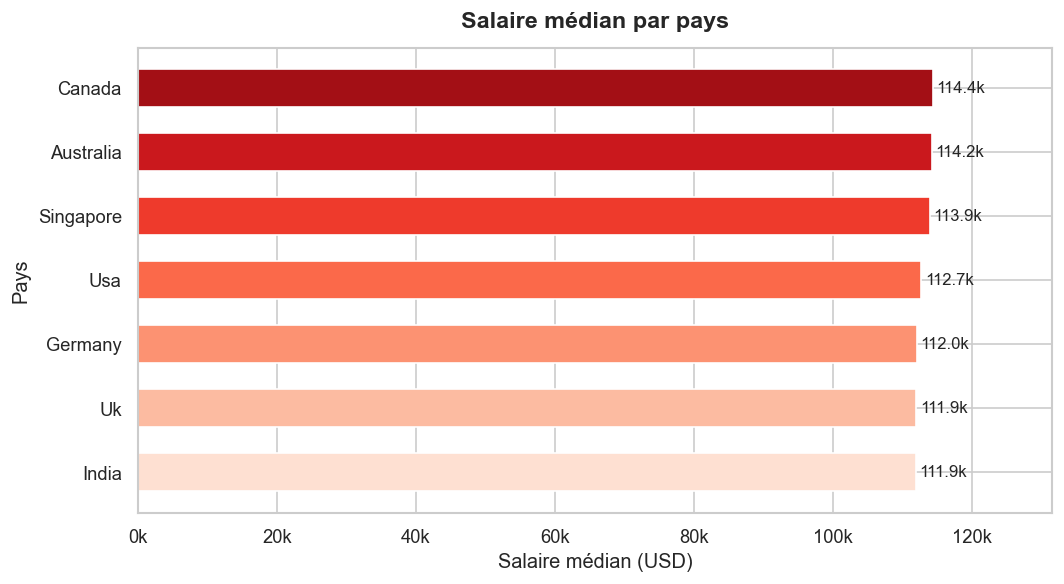

In [6]:
median_country = (
    df.groupby('country')['salary']
    .median()
    .sort_values(ascending=True)  # pour barplot horizontal lisible
    .reset_index()
)
median_country.columns = ['country', 'salary_median']

fig, ax = plt.subplots(figsize=(9, 5))

# Palette rose claire harmonisée
palette_rose = sns.color_palette("Reds", len(median_country))  # du clair au plus foncé

bars = ax.barh(
    median_country['country'].str.title(),
    median_country['salary_median'],
    color=palette_rose,
    edgecolor='white',
    height=0.6
)

# Afficher la valeur à côté de chaque barre
for bar, val in zip(bars, median_country['salary_median']):
    ax.text(val + 500, bar.get_y() + bar.get_height()/2,
            f'{val/1000:.1f}k', va='center', fontsize=10)

# Titres et axes
ax.set_title('Salaire médian par pays', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Salaire médian (USD)', fontsize=12)
ax.set_ylabel('Pays', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.set_xlim(0, median_country['salary_median'].max() * 1.15)

plt.tight_layout()

# Sauvegarde
plt.savefig(os.path.join(BASE_DIR, '..', 'figures', 'g4_salary_par_pays.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Graphique 5 : Salaire médian par secteur d'activité (Barplot)

**Objectif :** Identifier quels secteurs économiques rémunèrent le mieux  
les professionnels de la Data et de l'IA.

C:\Users\Admin\AppData\Local\Temp\ipykernel_9968\813940819.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(median_industry['industry'].str.title(), rotation=15, ha='right', fontsize=11)


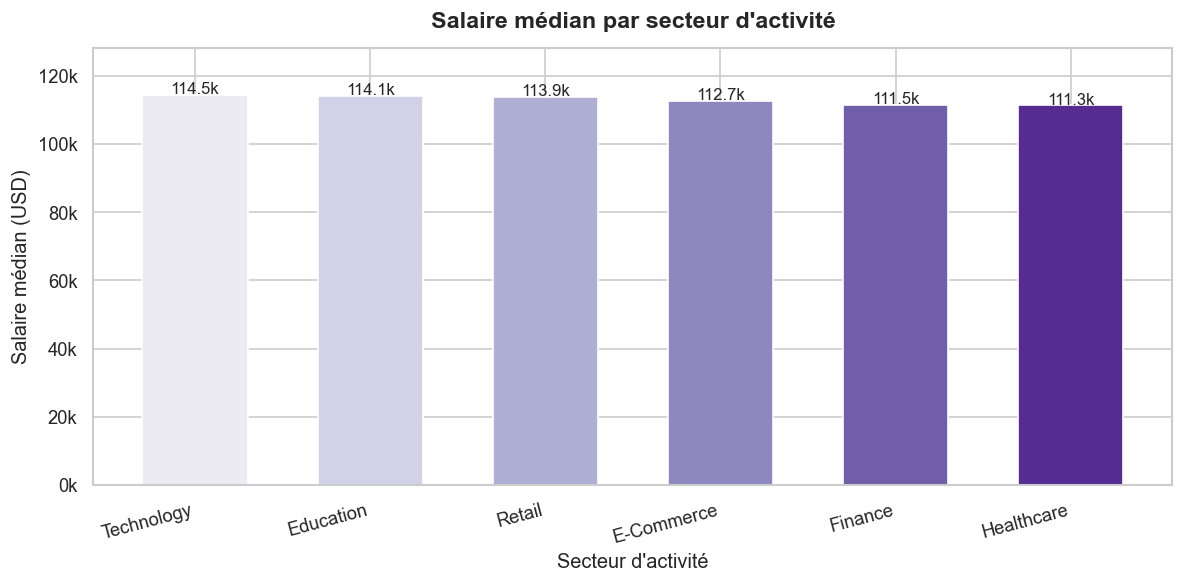

In [7]:
median_industry = (
    df.groupby('company_industry')['salary']
    .median()
    .sort_values(ascending=False)
    .reset_index()
)
median_industry.columns = ['industry', 'salary_median']

fig, ax = plt.subplots(figsize=(10, 5))

# Palette mauve harmonisée
palette_mauve = sns.color_palette("Purples", len(median_industry))  # du clair au foncé

bars = ax.bar(
    median_industry['industry'].str.title(),
    median_industry['salary_median'],
    color=palette_mauve,
    edgecolor='white',
    width=0.6
)

# Afficher la valeur au-dessus de chaque barre
for bar, val in zip(bars, median_industry['salary_median']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 300,
            f'{val/1000:.1f}k', ha='center', fontsize=10)

# Titres et axes
ax.set_title("Salaire médian par secteur d'activité", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Secteur d'activité", fontsize=12)
ax.set_ylabel('Salaire médian (USD)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.set_ylim(0, median_industry['salary_median'].max() * 1.12)

# Rotation des labels pour lisibilité
ax.set_xticklabels(median_industry['industry'].str.title(), rotation=15, ha='right', fontsize=11)

plt.tight_layout()

# Sauvegarde
plt.savefig(os.path.join(BASE_DIR, '..', 'figures', 'g5_salary_par_secteur.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Graphique 6 : Années d'expérience vs Salaire (Scatter plot)

**Objectif :** Voir si une relation linéaire (droite) existe entre `years_experience` et `salary`.  
C'est une question clé car si la relation est forte, `years_experience` sera une variable  
très utile pour le modèle ML.

**Couleur des points** = niveau d'expérience (Entry / Mid / Senior)

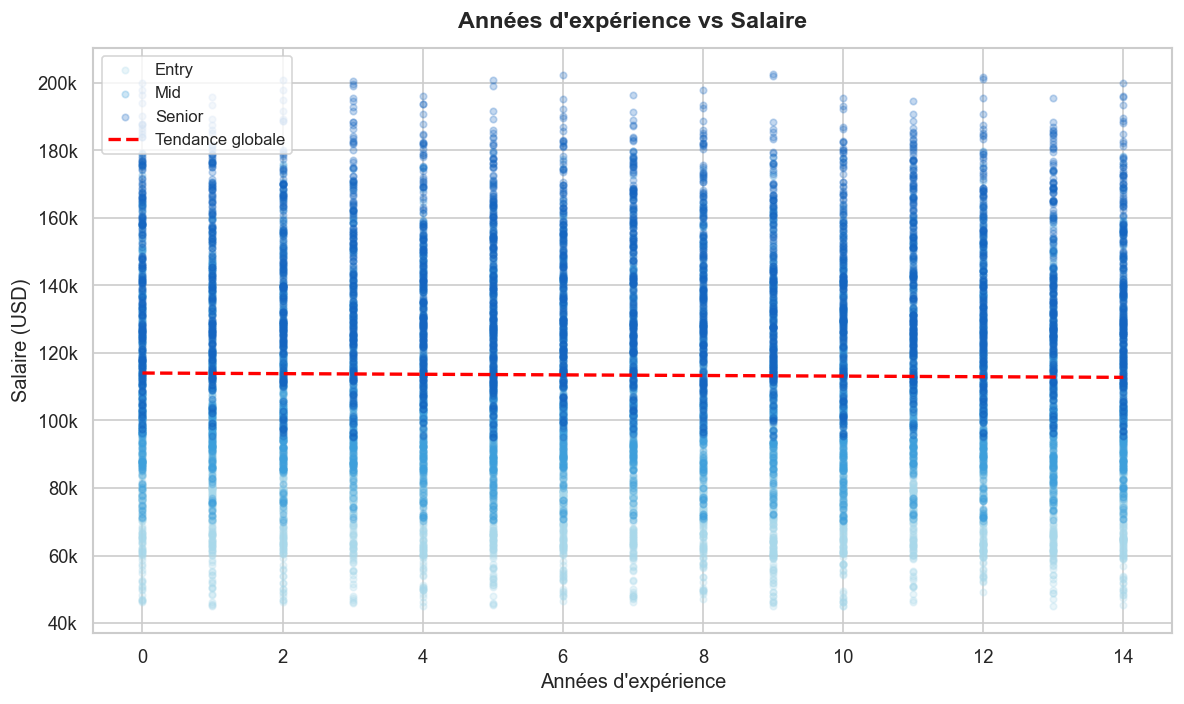

Corrélation years_experience / salary : -0.013


In [8]:
palette_exp = {'entry': '#a8d8ea', 'mid': '#3d9fdb', 'senior': '#1565c0'}

fig, ax = plt.subplots(figsize=(10, 6))

for niveau, couleur in palette_exp.items():
    sous = df[df['experience_level'] == niveau]
    ax.scatter(
        sous['years_experience'],
        sous['salary'],
        alpha=0.25,
        s=15,
        color=couleur,
        label=niveau.title()
    )

# Ligne de tendance globale
z = np.polyfit(df['years_experience'], df['salary'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['years_experience'].min(), df['years_experience'].max(), 100)
ax.plot(x_line, p(x_line), color='red', linewidth=2, linestyle='--', label='Tendance globale')

ax.set_title("Années d'expérience vs Salaire", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Années d'expérience", fontsize=12)
ax.set_ylabel('Salaire (USD)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, '..', 'figures', 'g6_experience_vs_salary.png'), dpi=150, bbox_inches='tight')
plt.show()

corr = df['years_experience'].corr(df['salary'])
print(f'Corrélation years_experience / salary : {corr:.3f}')

## Graphique 7 : Carte de corrélations (Heatmap)

**Objectif :** Voir d'un seul coup d'œil quelles variables sont les plus liées à `salary`.

**Comment lire une heatmap de corrélations ?**
- Valeur proche de **+1** (bleu foncé) → quand la variable monte, le salary monte aussi
- Valeur proche de **−1** (rouge foncé) → quand la variable monte, le salary descend
- Valeur proche de **0** (blanc/clair) → aucune relation linéaire

On utilise ici le dataset **nettoyé** (avec les colonnes numériques encodées)  
pour avoir les vraies corrélations utilisées par le modèle ML.

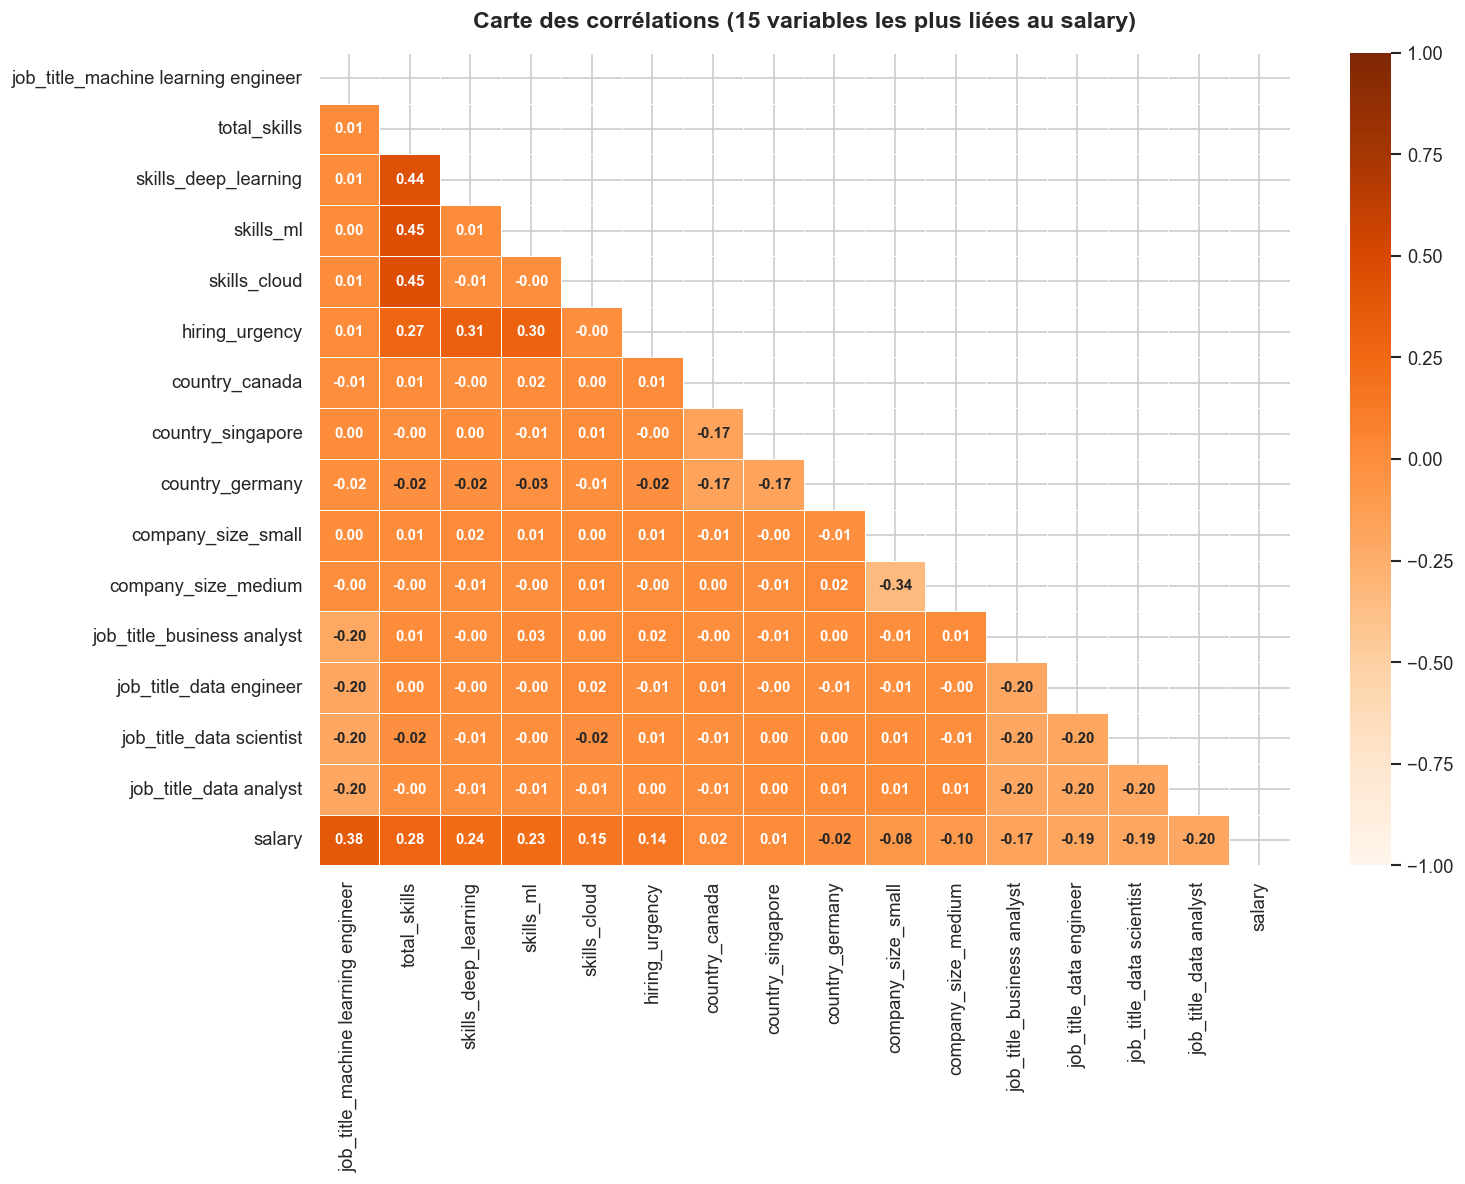

Top 5 variables positivement corrélées avec salary :
job_title_machine learning engineer    0.376
total_skills                           0.282
skills_deep_learning                   0.242
skills_ml                              0.232
skills_cloud                           0.153
Name: salary, dtype: object

Top 5 variables négativement corrélées avec salary :
company_size_medium           -0.100
job_title_business analyst    -0.171
job_title_data engineer       -0.192
job_title_data scientist      -0.195
job_title_data analyst        -0.203
Name: salary, dtype: object


In [9]:
CLEAN_PATH = os.path.join(BASE_DIR, '..', 'data', 'processed', 'AI_Job_Market_Dataset_Cleaned.csv')
df_clean = pd.read_csv(CLEAN_PATH)

# Corrélations avec salary, triées
corr_salary = df_clean.corr()['salary'].drop('salary').sort_values(ascending=False)

# Garder les 15 variables les plus corrélées (positif + négatif)
top_pos = corr_salary.head(8).index.tolist()
top_neg = corr_salary.tail(7).index.tolist()
top_vars = top_pos + top_neg + ['salary']

corr_matrix = df_clean[top_vars].corr()

fig, ax = plt.subplots(figsize=(13, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # masque triangle supérieur

# Palette orange pour distinguer de mauve
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='Oranges',  # dégradé orange
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 9, 'weight': 'bold'},
    ax=ax
)

ax.set_title('Carte des corrélations (15 variables les plus liées au salary)',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, '..', 'figures', 'g7_heatmap_correlations.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Affichage des top corrélations
print('Top 5 variables positivement corrélées avec salary :')
print(corr_salary.head(5).apply(lambda x: f'{x:.3f}'))
print('\nTop 5 variables négativement corrélées avec salary :')
print(corr_salary.tail(5).apply(lambda x: f'{x:.3f}'))

## Graphique 8 : Nombre de compétences vs Salaire (Barplot)

**Objectif :** Vérifier si un candidat avec plus de compétences techniques  
(Python + SQL + ML + Deep Learning + Cloud) obtient un salaire plus élevé.

`total_skills` varie de 0 (aucune compétence requise) à 5 (toutes les compétences).

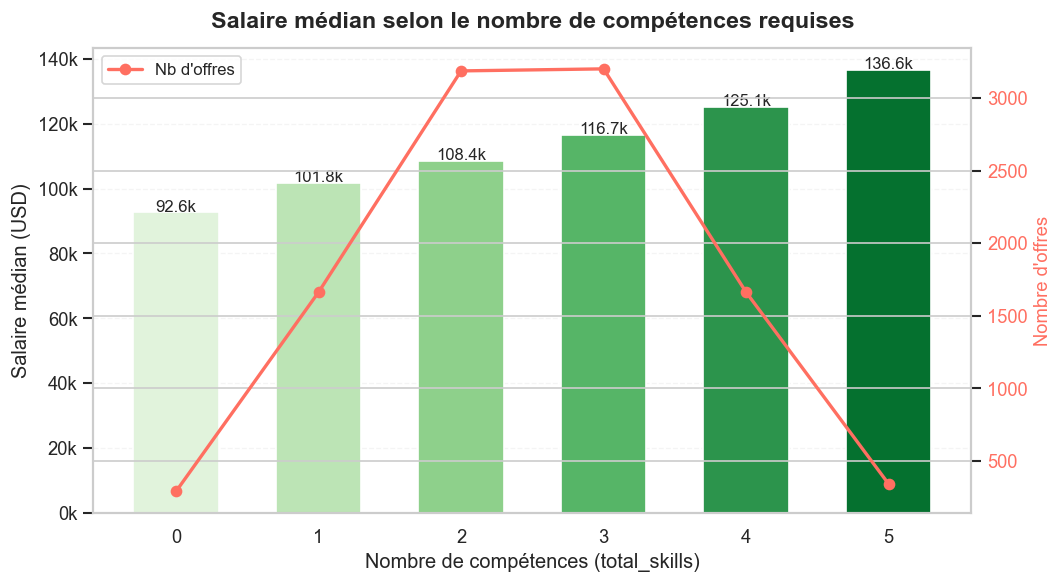

 total_skills  salary_median  nb_offres
            0        92619.5        290
            1       101806.5       1662
            2       108410.0       3186
            3       116651.5       3200
            4       125124.0       1662
            5       136633.0        341


In [10]:
median_skills = (
    df.groupby('total_skills')['salary']
    .agg(['median', 'count'])
    .reset_index()
)
median_skills.columns = ['total_skills', 'salary_median', 'nb_offres']

fig, ax1 = plt.subplots(figsize=(9, 5))

# Barplot salary médian en vert harmonisé
palette_vert = sns.color_palette("Greens", len(median_skills))  # du vert clair au foncé

bars = ax1.bar(
    median_skills['total_skills'].astype(str),
    median_skills['salary_median'],
    color=palette_vert,
    edgecolor='white',
    width=0.6
)

# Afficher la valeur au-dessus de chaque barre
for bar, val in zip(bars, median_skills['salary_median']):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 400,
             f'{val/1000:.1f}k', ha='center', fontsize=10)

# Axe secondaire : nombre d'offres
ax2 = ax1.twinx()
ax2.plot(
    median_skills['total_skills'].astype(str),
    median_skills['nb_offres'],
    color='#FF6F61', marker='o', linewidth=2, markersize=6, label="Nb d'offres"
)
ax2.set_ylabel("Nombre d'offres", fontsize=11, color='#FF6F61')
ax2.tick_params(axis='y', labelcolor='#FF6F61')
ax2.legend(loc='upper left', fontsize=10)

# Titres et axes
ax1.set_title('Salaire médian selon le nombre de compétences requises',
              fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Nombre de compétences (total_skills)', fontsize=12)
ax1.set_ylabel('Salaire médian (USD)', fontsize=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Grille très légère pour ne pas cacher les nombres
ax1.grid(True, which='major', axis='y', linestyle='--', alpha=0.2, linewidth=0.8)
ax1.grid(False, axis='x')  # désactiver grille verticale

plt.tight_layout()

# Sauvegarde
plt.savefig(os.path.join(BASE_DIR, '..', 'figures', 'g8_skills_vs_salary.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Affichage des statistiques
print(median_skills.to_string(index=False))

##  Récapitulatif des observations

Après analyse des 8 graphiques, voici les conclusions principales :

| Variable | Influence sur le salary | Observation |
|---|---|---|
| `job_title` | Forte | AI Engineer et ML Engineer sont bien au-dessus |
| `experience_level` | Forte | Entry → Mid → Senior : progression claire |
| `total_skills` | Modérée | Plus de compétences = meilleur salaire |
| `years_experience` | Modérée | Corrélation positive mais dispersée |
| `company_industry` | Faible | Légères différences entre secteurs |
| `country` | Faible | Peu de variation entre pays dans ce dataset |

**→ Les variables les plus importantes pour le modèle ML seront :**  
`job_title`, `experience_level` (ou `years_experience`), `total_skills`, `skills_ml`, `skills_deep_learning`